In [1]:
from google.colab import drive
#drive.flush_and_unmount()
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
%cd gdrive/MyDrive/ROBUST_TIME SERIES_CLASSIFICATION/AnomalyBERT-main

/content/gdrive/MyDrive/ROBUST_TIME SERIES_CLASSIFICATION/AnomalyBERT-main


In [38]:
# =========================================================
# Window classifier with train-normal z-score normalization,
# robust DataLoader, and torch.amp AMP API (no deprecations)
# =========================================================
import os, math, gc, json, random, warnings
from typing import Tuple, List, Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, precision_recall_fscore_support, accuracy_score,
    precision_score, recall_score, f1_score
)

# ---------- Notebook/Colab-safe multiprocessing ----------
import torch.multiprocessing as mp
try:
    mp.set_start_method("spawn", force=True)
except RuntimeError:
    pass
try:
    torch.multiprocessing.set_sharing_strategy("file_system")
except RuntimeError:
    pass

# Optional: a small matmul precision bump on Ampere+
torch.set_float32_matmul_precision("high")

In [104]:


# -------------------------
# Config
# -------------------------
#CSV_PATH = "/content/gdrive/MyDrive/DATASETS/TIME_SERIES_MULTI_V_DATA/SWAT_NORMALIZED.csv"  # <- set me
#CSV_PATH = "/content/gdrive/MyDrive/DATASETS/TIME_SERIES_MULTI_V_DATA/MSL/NORMALIZED_MSL.csv"
#CSV_PATH= "/content/gdrive/MyDrive/DATASETS/TIME_SERIES_MULTI_V_DATA/SMAP/NORMALIZED_SMAP.csv"
CSV_PATH= "/content/gdrive/MyDrive/DATASETS/TIME_SERIES_MULTI_V_DATA/WADI/WADI_NORMALIZED_DATA_NEW.csv"
LABEL_COL = "Label"
MAX_ROWS = 100_000

VAL_FRACTION  = 0.20     # chronological split
TEST_FRACTION = 0.20

WINDOW       = 100
TRAIN_STRIDE = 20
VAL_STRIDE   = 20
TEST_STRIDE  = 20

# Synthetic patching (train + val)
DEGRADE_MIN = 0.25
DEGRADE_MAX = 0.75
ANOMALY_BANK_MAX = 6000
VAL_POS_FRAC = 0.25      # keep same as "older version"

# Training
EPOCHS       = 20
BATCH_SIZE   = 128
LR           = 3e-4
WEIGHT_DECAY = 1e-4
CLIP_NORM    = 1.0

DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_TYPE  = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP      = torch.cuda.is_available()
PIN_MEMORY   = torch.cuda.is_available()

# DataLoader robustness in notebooks: start with workers OFF
NUM_WORKERS = 0
PERSIST     = False

EVAL_BATCH  = 1024

# Model
MODEL_KIND = "plain" #"plain"     # "plain" | "bert"
D_MODEL = 128
NHEAD   = 4
NLAYERS = 2
FF_MULT = 4
PDROP   = 0.2
PATCH_SIZE = 10          # WINDOW should be multiple ideally

# Repro
SEED = 1337
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

In [105]:
# -------------------------
# Utilities
# -------------------------
def sliding_windows(x: np.ndarray, y: np.ndarray, win: int, stride: int):
    L = len(x)
    xs, ys = [], []
    for s in range(0, L - win + 1, stride):
        xs.append(x[s:s+win])
        ys.append(y[s:s+win])
    if not xs:
        return (np.zeros((0, win, x.shape[1]), dtype=np.float32),
                np.zeros((0, win), dtype=np.int32))
    return np.stack(xs).astype(np.float32), np.stack(ys).astype(np.int32)

def window_label_from_series(ywin: np.ndarray) -> np.ndarray:
    return (ywin.sum(axis=1) > 0).astype(np.int32)

def extract_anomaly_spans(y: np.ndarray) -> List[Tuple[int,int]]:
    spans, i, L = [], 0, len(y)
    while i < L:
        if y[i] == 1:
            j = i
            while j + 1 < L and y[j+1] == 1: j += 1
            spans.append((i, j+1))
            i = j + 1
        else:
            i += 1
    return spans

def resample_len(x: np.ndarray, out_len: int) -> np.ndarray:
    T, D = x.shape
    if T == out_len: return x.copy()
    old = np.linspace(0.0, 1.0, T, dtype=np.float32)
    new = np.linspace(0.0, 1.0, out_len, dtype=np.float32)
    y = np.empty((out_len, D), dtype=np.float32)
    for d in range(D):
        y[:, d] = np.interp(new, old, x[:, d])
    return y

def aug_light(x: np.ndarray) -> np.ndarray:
    T, D = x.shape
    s = np.random.uniform(0.95, 1.05, size=(1, D)).astype(np.float32)
    y = x * s
    y = y + np.random.normal(0, 0.01, size=y.shape).astype(np.float32)
    end = np.random.uniform(-0.05, 0.05, size=(1, D)).astype(np.float32)
    trend = np.linspace(0, 1, T, dtype=np.float32).reshape(T,1) * end
    return y + trend

def safe_auc(ytrue: np.ndarray, yscore: np.ndarray) -> float:
    try:
        if len(np.unique(ytrue)) < 2: return float('nan')
        return roc_auc_score(ytrue, yscore)
    except Exception:
        return float('nan')

In [106]:
# -------------------------
# Load & split (chronological)
# -------------------------
df = pd.read_csv(CSV_PATH).iloc[:MAX_ROWS].dropna()
X_all = df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_all = df[LABEL_COL].values.astype(np.int32)
N = len(df)

n_test = int(N * TEST_FRACTION)
n_val  = int(N * VAL_FRACTION)
n_train = N - n_val - n_test
assert n_train > WINDOW, "Training split too small for given WINDOW."

X_train_raw, y_train_raw = X_all[:n_train],               y_all[:n_train]
X_val_raw,   y_val_raw   = X_all[n_train:n_train+n_val],  y_all[n_train:n_train+n_val]
X_test_raw,  y_test_raw  = X_all[n_train+n_val:],         y_all[n_train+n_val:]

# -------------------------
# Pools (unnormalized)
# -------------------------
X_train_norm_pool = X_train_raw[y_train_raw==0]
X_train_anom_pool = X_train_raw[y_train_raw==1]
X_val_norm_pool   = X_val_raw[y_val_raw==0]
X_val_anom_pool   = X_val_raw[y_val_raw==1]
X_test_seq        = X_test_raw

print(f"Pools | train_norm={len(X_train_norm_pool)}  train_anom={len(X_train_anom_pool)}  "
      f"val_norm={len(X_val_norm_pool)}  val_anom={len(X_val_anom_pool)}  test_seq={len(X_test_seq)}")


Pools | train_norm=57892  train_anom=2108  val_norm=16038  val_anom=3962  test_seq=20000


In [107]:
# -------------------------
# NORMALIZATION — z-score from TRAIN NORMALS only
# -------------------------
def fit_zscore(X: np.ndarray):
    mu = X.mean(axis=0, keepdims=True).astype(np.float32)
    sd = X.std(axis=0, keepdims=True).astype(np.float32)
    sd[sd < 1e-8] = 1e-8
    return mu, sd

def apply_zscore(X: np.ndarray, mu: np.ndarray, sd: np.ndarray):
    return ((X - mu) / sd).astype(np.float32)

assert len(X_train_norm_pool) > 0, "Need train normals to fit normalization."
mu_norm, sd_norm = fit_zscore(X_train_norm_pool)

X_train_norm_pool = apply_zscore(X_train_norm_pool, mu_norm, sd_norm)
X_train_anom_pool = apply_zscore(X_train_anom_pool, mu_norm, sd_norm)
X_val_norm_pool   = apply_zscore(X_val_norm_pool,   mu_norm, sd_norm)
X_val_anom_pool   = apply_zscore(X_val_anom_pool,   mu_norm, sd_norm)
X_test_seq        = apply_zscore(X_test_seq,        mu_norm, sd_norm)

# Recreate full normalized sequences in original chronological order
X_train = apply_zscore(X_train_raw, mu_norm, sd_norm)
X_val   = apply_zscore(X_val_raw,   mu_norm, sd_norm)
X_test  = apply_zscore(X_test_raw,  mu_norm, sd_norm)

print("[norm] z-score fitted on TRAIN NORMALS and applied.")

# -------------------------
# Build anomaly bank (from TRAIN anomalies)
# -------------------------
def build_anomaly_bank_from_train() -> List[np.ndarray]:
    spans = extract_anomaly_spans(y_train_raw)
    rng = np.random.default_rng(SEED); rng.shuffle(spans)
    spans = spans[:ANOMALY_BANK_MAX]
    return [ apply_zscore(X_train_raw[a:b].astype(np.float32), mu_norm, sd_norm) for a,b in spans ]

bank = build_anomaly_bank_from_train()
if len(bank) == 0:
    raise RuntimeError("No anomaly spans in TRAIN to build patch bank.")

# -------------------------
# TRAIN windows: normals -> degraded copy
# -------------------------
Xw_tr, Yw_tr = sliding_windows(X_train, y_train_raw, WINDOW, TRAIN_STRIDE)
mask_normal_win = (Yw_tr.sum(axis=1) == 0)
Xw_tr = Xw_tr[mask_normal_win]

Ntr = len(Xw_tr)
Xw_deg = np.empty_like(Xw_tr, dtype=np.float32)

for i in range(Ntr):
    x = Xw_tr[i].copy()
    frac = np.random.uniform(DEGRADE_MIN, DEGRADE_MAX)
    Ld   = max(4, int(round(frac * WINDOW)))
    s = np.random.randint(0, WINDOW - Ld + 1); e = s + Ld
    patch = bank[np.random.randint(0, len(bank))]
    patch = resample_len(patch, Ld)
    patch = aug_light(patch)
    # local amplitude match
    mu_x  = x[s:e].mean(axis=0, keepdims=True)
    sd_x  = x[s:e].std(axis=0, keepdims=True) + 1e-6
    mu_p  = patch.mean(axis=0, keepdims=True)
    sd_p  = patch.std(axis=0, keepdims=True) + 1e-6
    patch = (patch - mu_p) / sd_p * sd_x + mu_x
    x[s:e] = patch
    Xw_deg[i] = x

X_train_cls = np.concatenate([Xw_tr, Xw_deg], axis=0)
y_train_cls = np.concatenate([np.zeros(Ntr, np.int32), np.ones(Ntr, np.int32)], axis=0)
perm = np.random.default_rng(SEED).permutation(len(X_train_cls))
X_train_cls, y_train_cls = X_train_cls[perm], y_train_cls[perm]


[norm] z-score fitted on TRAIN NORMALS and applied.


In [108]:
# -------------------------
# VAL (synthetic, deterministic): patch subset of val-normal windows
# -------------------------
Xv_all, Yv_all = sliding_windows(X_val, y_val_raw, WINDOW, VAL_STRIDE)
v_norm_mask = (Yv_all.sum(axis=1) == 0)
Xv_norm = Xv_all[v_norm_mask]

Nv = len(Xv_norm)
Nv_pos = int(round(VAL_POS_FRAC * Nv))
rng = np.random.default_rng(12345)  # fixed seed => deterministic val
idx_perm = rng.permutation(Nv)
idx_pos, idx_neg = idx_perm[:Nv_pos], idx_perm[Nv_pos:]

Xv_pos = np.empty((Nv_pos, WINDOW, Xv_norm.shape[2]), dtype=np.float32)
for k, i in enumerate(idx_pos):
    x = Xv_norm[i].copy()
    frac = rng.uniform(DEGRADE_MIN, DEGRADE_MAX)
    Ld   = max(4, int(round(frac * WINDOW)))
    s = rng.integers(0, WINDOW - Ld + 1); e = s + Ld
    patch = bank[rng.integers(0, len(bank))]
    patch = resample_len(patch, Ld)
    patch = aug_light(patch)
    mu_x  = x[s:e].mean(axis=0, keepdims=True)
    sd_x  = x[s:e].std(axis=0, keepdims=True) + 1e-6
    mu_p  = patch.mean(axis=0, keepdims=True)
    sd_p  = patch.std(axis=0, keepdims=True) + 1e-6
    patch = (patch - mu_p) / sd_p * sd_x + mu_x
    x[s:e] = patch
    Xv_pos[k] = x

Xv_neg = Xv_norm[idx_neg]
Xv_syn = np.concatenate([Xv_neg, Xv_pos], axis=0)
yv_syn = np.concatenate([np.zeros(len(Xv_neg), np.int32), np.ones(len(Xv_pos), np.int32)], axis=0)


In [109]:


# -------------------------
# TEST windows (real labels → window label)
# -------------------------
Xt_win, Yt_win = sliding_windows(X_test, y_test_raw, WINDOW, TEST_STRIDE)
yt_lbl = window_label_from_series(Yt_win)

print(f"TRAIN windows: {len(X_train_cls)} (balanced)")
print(f"VAL (synthetic, deterministic): {len(Xv_syn)}  pos={int(yv_syn.sum())} ({100*yv_syn.mean():.1f}%)")
print(f"TEST windows: {len(Xt_win)}  pos(real)={int(yt_lbl.sum())} ({100*yt_lbl.mean():.1f}%)")

# -------------------------
# Preflight checks (catch silent worker errors)
# -------------------------
def check_array(name, X):
    assert isinstance(X, np.ndarray), f"{name} not ndarray"
    assert X.dtype == np.float32, f"{name} dtype {X.dtype}"
    assert X.ndim == 3, f"{name} ndim {X.ndim}"
    assert X.shape[1] == WINDOW, f"{name} window len {X.shape[1]} != {WINDOW}"
    assert np.all(np.isfinite(X)), f"NaN/Inf in {name}"

def check_labels(name, y):
    assert isinstance(y, np.ndarray), f"{name} not ndarray"
    assert y.ndim == 1, f"{name} ndim {y.ndim}"
    assert y.dtype in (np.int32, np.int64), f"{name} dtype {y.dtype}"

check_array("X_train_cls", X_train_cls); check_labels("y_train_cls", y_train_cls)
check_array("Xv_syn", Xv_syn);           check_labels("yv_syn", yv_syn)
check_array("Xt_win", Xt_win);           check_labels("yt_lbl", yt_lbl.astype(np.int32))

# -------------------------
# Datasets / loaders
# -------------------------
class WinClsDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i], dtype=torch.float32)

def collate_safe(batch):
    xs, ys = zip(*batch)
    xs = [x.contiguous() for x in xs]
    return torch.stack(xs, 0), torch.stack(ys, 0)

train_ds = WinClsDataset(X_train_cls, y_train_cls)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=PERSIST,
    collate_fn=collate_safe
)

TRAIN windows: 5762 (balanced)
VAL (synthetic, deterministic): 778  pos=194 (24.9%)
TEST windows: 996  pos(real)=34 (3.4%)


In [110]:
# -------------------------
# Models
# -------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 10000):
        super().__init__()
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe, persistent=False)
    def forward(self, x):  # [B,T,D]
        T = x.size(1)
        return x + self.pe[:T]

def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    B, T, D = x.shape
    Lp = (T // patch_size) * patch_size
    x = x[:, :Lp, :]
    return x.reshape(B, Lp // patch_size, patch_size * D)

class TransformerWindowClassifier(nn.Module):
    def __init__(self, d_in: int, d_model: int, nhead: int, nlayers: int, ff_mult: int, pdrop: float, patch_size: int):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Linear(d_in * patch_size, d_model)
        enc = nn.TransformerEncoderLayer(d_model, nhead, ff_mult*d_model, dropout=pdrop,
                                         batch_first=True, activation='gelu')
        self.enc = nn.TransformerEncoder(enc, num_layers=nlayers)
        self.pos = PositionalEncoding(d_model)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)
        nn.init.xavier_uniform_(self.proj.weight); nn.init.zeros_(self.proj.bias)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)
    def forward(self, x):  # x: [B,T,D]
        x = patchify(x, self.patch_size)
        h = self.proj(x)
        h = self.pos(h)
        h = self.enc(h)
        h = self.norm(h.mean(dim=1))
        return self.head(h).squeeze(-1)  # logits (B,)

class AnomalyBertWindowClassifier(nn.Module):
    def __init__(self, input_dim: int, model_dim: int = 128, num_heads: int = 4, num_layers: int = 2,
                 dropout: float = 0.2, max_len: int = 2048):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, model_dim))
        self.pos_embed = nn.Embedding(max_len + 1, model_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads, dim_feedforward=model_dim*4,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(model_dim)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(model_dim, 1)
        nn.init.trunc_normal_(self.pos_embed.weight, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)
    def forward(self, x):
        B, L, _ = x.shape
        z = self.input_proj(x)
        cls = self.cls_token.expand(B, 1, self.model_dim)
        z = torch.cat([cls, z], dim=1)
        pos_ids = torch.arange(L + 1, device=x.device).unsqueeze(0)
        z = self.drop(z + self.pos_embed(pos_ids))
        z = self.encoder(z)
        cls_out = self.norm(z[:, 0, :])
        return self.head(cls_out).squeeze(1)  # logits (B,)


In [111]:
# -------------------------
# Inference helpers (AMP via torch.amp)
# -------------------------
@torch.no_grad()
def infer_window_scores(model: nn.Module, Xw: np.ndarray) -> np.ndarray:
    if len(Xw) == 0: return np.zeros((0,), dtype=np.float32)
    model.eval()
    out = []
    for i in range(0, len(Xw), EVAL_BATCH):
        xb = torch.from_numpy(Xw[i:i+EVAL_BATCH]).float().to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE_TYPE, enabled=USE_AMP):
            logits = model(xb)
            probs = torch.sigmoid(logits).float().cpu().numpy()
        out.append(probs)
    return np.concatenate(out, axis=0)

def summarize(scores: np.ndarray, y_true: np.ndarray, thr: float) -> Dict[str, float]:
    y_pred = (scores >= thr).astype(np.int32)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    auc = safe_auc(y_true, scores)
    return {"Prec": float(prec), "Rec": float(rec), "F1": float(f1), "Acc": float(acc), "AUC": float(auc), "Thr": float(thr)}

def point_adjust(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    y_adj = y_pred.copy()
    spans, i, L = [], 0, len(y_true)
    while i < L:
        if y_true[i] == 1:
            j = i
            while j+1 < L and y_true[j+1] == 1: j += 1
            spans.append((i, j+1)); i = j+1
        else:
            i += 1
    for a,b in spans:
        if y_pred[a:b].max() == 1:
            y_adj[a:b] = 1
    return y_adj

def f1_point_adjusted(scores: np.ndarray, labels: np.ndarray, thr: float) -> float:
    y_pred = (scores >= thr).astype(np.int32)
    y_adj  = point_adjust(labels, y_pred)
    return f1_score(labels, y_adj, zero_division=0)

def tune_threshold(scores: np.ndarray, labels: np.ndarray, grid=np.linspace(0.01, 0.99, 99)) -> Dict[str, float]:
    best = {"thr": 0.5, "f1": -1.0, "f1_pa": -1.0}
    for t in grid:
        yhat = (scores >= t).astype(np.int32)
        _, _, f1, _ = precision_recall_fscore_support(labels, yhat, average='binary', zero_division=0)
        f1pa = f1_point_adjusted(scores, labels, t)
        if f1 > best["f1"]:
            best = {"thr": float(t), "f1": float(f1), "f1_pa": float(f1pa)}
    return best


**MSL**

In [112]:

D_in = X_train_cls.shape[2]
if MODEL_KIND == "plain":
    model = TransformerWindowClassifier(D_in, D_MODEL, NHEAD, NLAYERS, FF_MULT, PDROP, PATCH_SIZE).to(DEVICE)
else:
    model = AnomalyBertWindowClassifier(D_in, D_MODEL, NHEAD, NLAYERS, PDROP, max_len=WINDOW).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler(DEVICE_TYPE, enabled=USE_AMP)

In [113]:

# -------------------------
# Train (older behavior: per-epoch grid threshold on val-syn)
# -------------------------
metrics_hist = {"val_acc":[], "val_prec":[], "val_rec":[], "val_f1":[], "val_auc":[], "val_f1pa":[], "val_thr":[],
                "test_acc":[], "test_prec":[], "test_rec":[], "test_f1":[], "test_auc":[]}

print("Starting training …")
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE_TYPE, enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        scaler.step(opt); scaler.update()
        running += loss.item()

    # VAL — synthetic deterministic
    val_scores = infer_window_scores(model, Xv_syn)
    thr_stats  = tune_threshold(val_scores, yv_syn)     # classic per-epoch grid search
    thr = thr_stats["thr"]
    val_sum = summarize(val_scores, yv_syn, thr)
    val_sum["F1_PA"] = thr_stats["f1_pa"]

    # TEST — apply the same epoch's threshold
    test_scores = infer_window_scores(model, Xt_win)
    test_sum = summarize(test_scores, yt_lbl, thr)

    print(f"Epoch {epoch:02d}/{EPOCHS} — Train BCE loss: {running/max(1,len(train_loader)):.4f}\n"
          f" [Val (synthetic, deterministic) L={WINDOW}] "
          f"Acc={val_sum['Acc']:.3f}  Prec={val_sum['Prec']:.3f}  Rec={val_sum['Rec']:.3f}  "
          f"AUC={val_sum['AUC']:.3f}  F1={val_sum['F1']:.3f}  F1_PA={val_sum['F1_PA']:.3f}  Thr={val_sum['Thr']:.3f}")

    metrics_hist["val_acc"].append(val_sum["Acc"])
    metrics_hist["val_prec"].append(val_sum["Prec"])
    metrics_hist["val_rec"].append(val_sum["Rec"])
    metrics_hist["val_f1"].append(val_sum["F1"])
    metrics_hist["val_auc"].append(val_sum["AUC"])
    metrics_hist["val_f1pa"].append(val_sum["F1_PA"])
    metrics_hist["val_thr"].append(val_sum["Thr"])
    metrics_hist["test_acc"].append(test_sum["Acc"])
    metrics_hist["test_prec"].append(test_sum["Prec"])
    metrics_hist["test_rec"].append(test_sum["Rec"])
    metrics_hist["test_f1"].append(test_sum["F1"])
    metrics_hist["test_auc"].append(test_sum["AUC"])

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



Starting training …
Epoch 01/20 — Train BCE loss: 0.7331
 [Val (synthetic, deterministic) L=100] Acc=0.249  Prec=0.249  Rec=1.000  AUC=0.505  F1=0.399  F1_PA=0.399  Thr=0.010
Epoch 02/20 — Train BCE loss: 0.7114
 [Val (synthetic, deterministic) L=100] Acc=0.251  Prec=0.250  Rec=1.000  AUC=0.497  F1=0.400  F1_PA=0.400  Thr=0.310
Epoch 03/20 — Train BCE loss: 0.6985
 [Val (synthetic, deterministic) L=100] Acc=0.257  Prec=0.251  Rec=1.000  AUC=0.504  F1=0.402  F1_PA=0.402  Thr=0.300
Epoch 04/20 — Train BCE loss: 0.6758
 [Val (synthetic, deterministic) L=100] Acc=0.523  Prec=0.310  Rec=0.742  AUC=0.622  F1=0.437  F1_PA=0.547  Thr=0.520
Epoch 05/20 — Train BCE loss: 0.6328
 [Val (synthetic, deterministic) L=100] Acc=0.629  Prec=0.356  Rec=0.608  AUC=0.677  F1=0.450  F1_PA=0.646  Thr=0.570
Epoch 06/20 — Train BCE loss: 0.5555
 [Val (synthetic, deterministic) L=100] Acc=0.653  Prec=0.395  Rec=0.737  AUC=0.736  F1=0.514  F1_PA=0.639  Thr=0.520
Epoch 07/20 — Train BCE loss: 0.4929
 [Val (synthe

**SWAT**

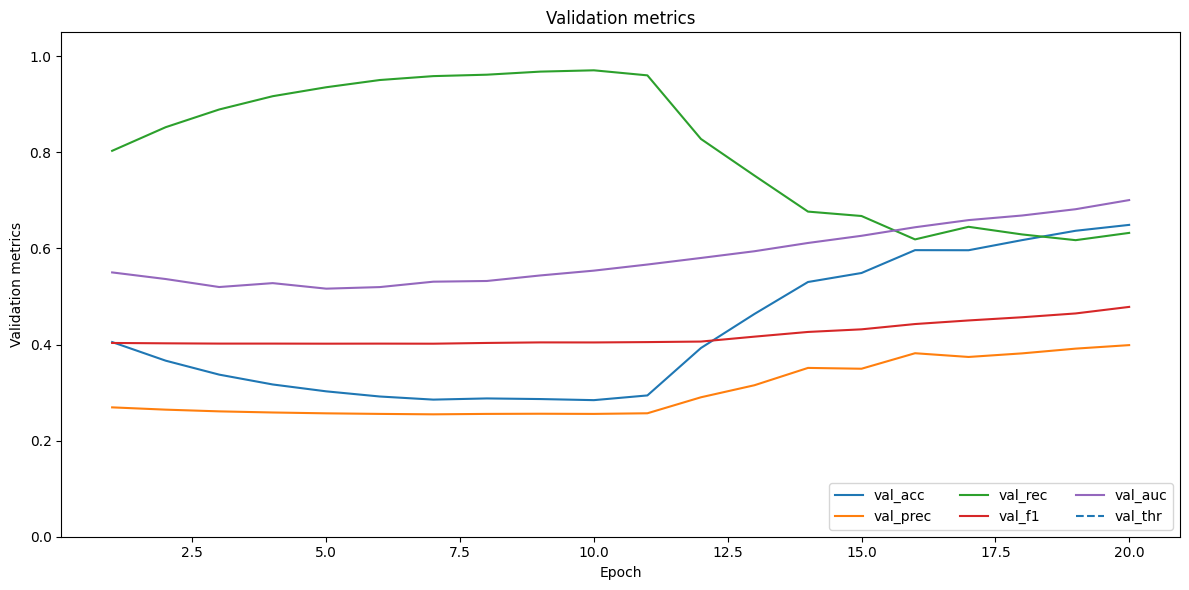

In [73]:

# -------------------------
# Plot metrics (one chart)
# -------------------------
import matplotlib.pyplot as plt

def ema(x, a=0.25):
    out, m = [], None
    for v in x:
        m = v if m is None else a*v + (1-a)*m
        out.append(m)
    return np.array(out)

epochs = np.arange(1, len(metrics_hist["val_auc"])+1)
plt.figure(figsize=(12,6))
ax = plt.gca()
for k in ["val_acc","val_prec","val_rec","val_f1","val_auc"]:
    ax.plot(epochs, ema(metrics_hist[k], 0.25), label=k)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation metrics")

# ax2 = ax.twinx()
# ax2.plot(epochs, metrics_hist["val_thr"], "--", label="val_thr")
# ax2.set_ylabel("Threshold")

lines, labels = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lab2, loc="lower right", ncol=3)
plt.title("Validation metrics")
plt.tight_layout()
plt.show()

**SWAT plain**

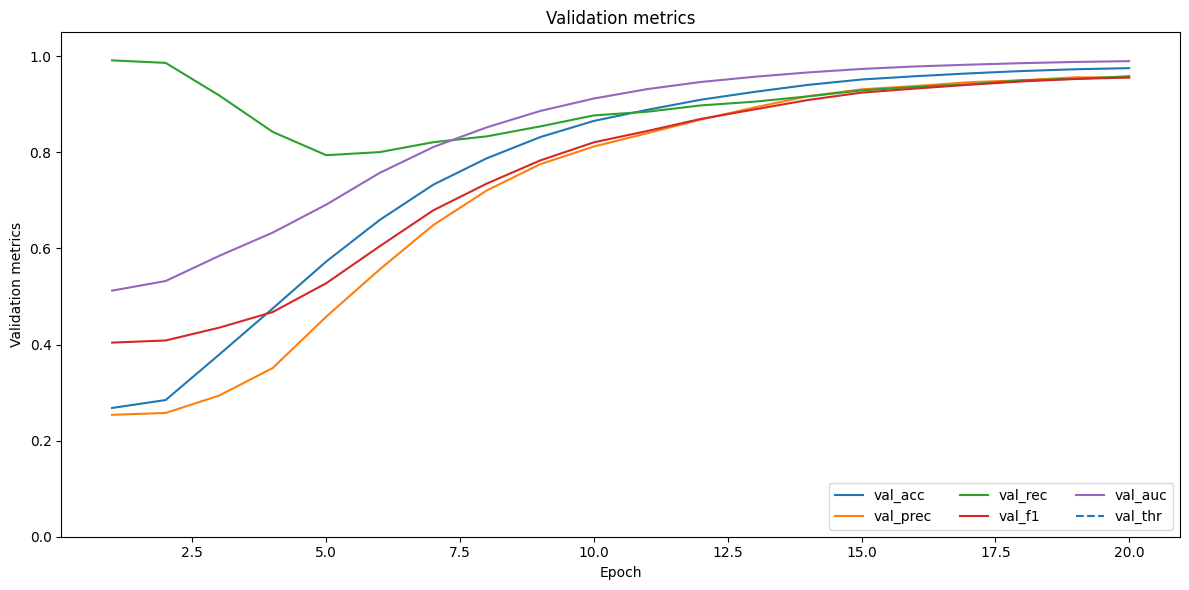

In [61]:

# -------------------------
# Plot metrics (one chart)
# -------------------------
import matplotlib.pyplot as plt

def ema(x, a=0.25):
    out, m = [], None
    for v in x:
        m = v if m is None else a*v + (1-a)*m
        out.append(m)
    return np.array(out)

epochs = np.arange(1, len(metrics_hist["val_auc"])+1)
plt.figure(figsize=(12,6))
ax = plt.gca()
for k in ["val_acc","val_prec","val_rec","val_f1","val_auc"]:
    ax.plot(epochs, ema(metrics_hist[k], 0.25), label=k)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation metrics")

# ax2 = ax.twinx()
# ax2.plot(epochs, metrics_hist["val_thr"], "--", label="val_thr")
# ax2.set_ylabel("Threshold")

lines, labels = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lab2, loc="lower right", ncol=3)
plt.title("Validation metrics")
plt.tight_layout()
plt.show()

**MSL PLAIN**


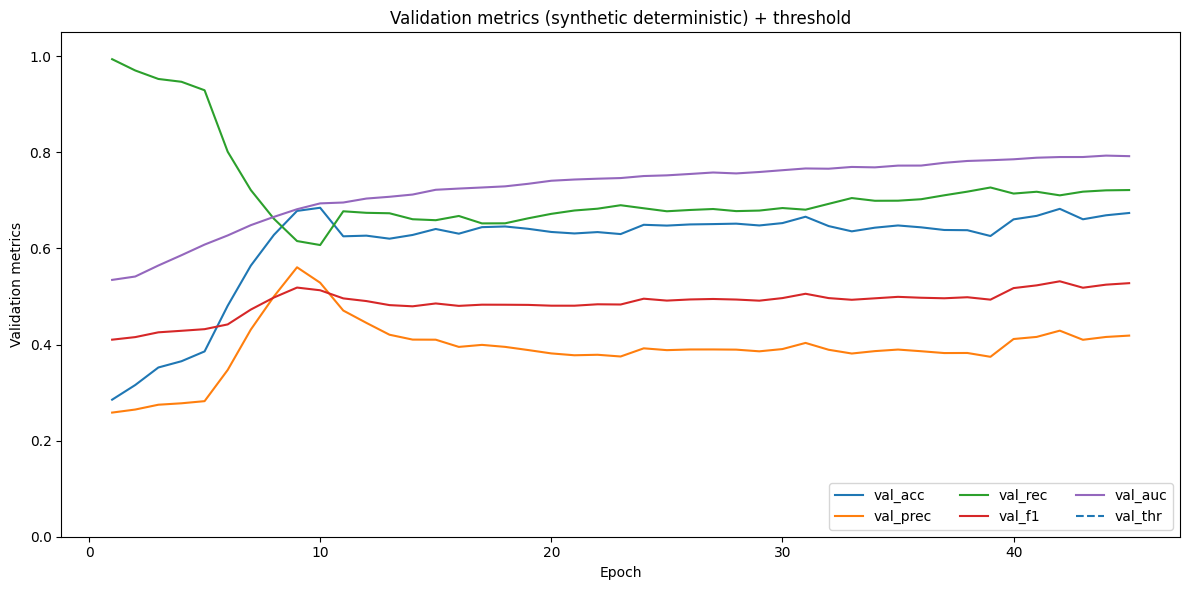

In [32]:

# -------------------------
# Plot metrics (one chart)
# -------------------------
import matplotlib.pyplot as plt

def ema(x, a=0.25):
    out, m = [], None
    for v in x:
        m = v if m is None else a*v + (1-a)*m
        out.append(m)
    return np.array(out)

epochs = np.arange(1, len(metrics_hist["val_auc"])+1)
plt.figure(figsize=(12,6))
ax = plt.gca()
for k in ["val_acc","val_prec","val_rec","val_f1","val_auc"]:
    ax.plot(epochs, ema(metrics_hist[k], 0.25), label=k)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation metrics")

# ax2 = ax.twinx()
# ax2.plot(epochs, metrics_hist["val_thr"], "--", label="val_thr")
# ax2.set_ylabel("Threshold")

lines, labels = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lab2, loc="lower right", ncol=3)
plt.title("Validation metrics (synthetic deterministic) + threshold")
plt.tight_layout()
plt.show()

**MSL BERT**

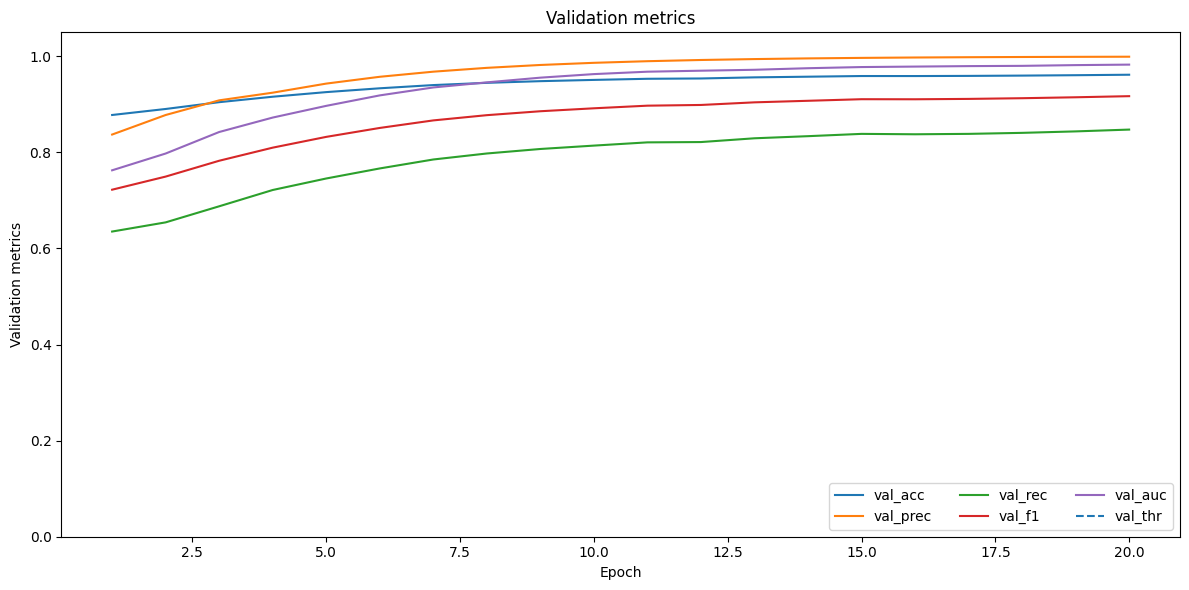

In [16]:

# -------------------------
# Plot metrics (one chart)
# -------------------------
import matplotlib.pyplot as plt

def ema(x, a=0.25):
    out, m = [], None
    for v in x:
        m = v if m is None else a*v + (1-a)*m
        out.append(m)
    return np.array(out)

epochs = np.arange(1, len(metrics_hist["val_auc"])+1)
plt.figure(figsize=(12,6))
ax = plt.gca()
for k in ["val_acc","val_prec","val_rec","val_f1","val_auc"]:
    ax.plot(epochs, ema(metrics_hist[k], 0.25), label=k)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation metrics")

# ax2 = ax.twinx()
# ax2.plot(epochs, metrics_hist["val_thr"], "--", label="val_thr")
# ax2.set_ylabel("Threshold")

lines, labels = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lab2, loc="lower right", ncol=3)
plt.title("Validation metrics")
plt.tight_layout()
plt.show()

**SMD BERT**


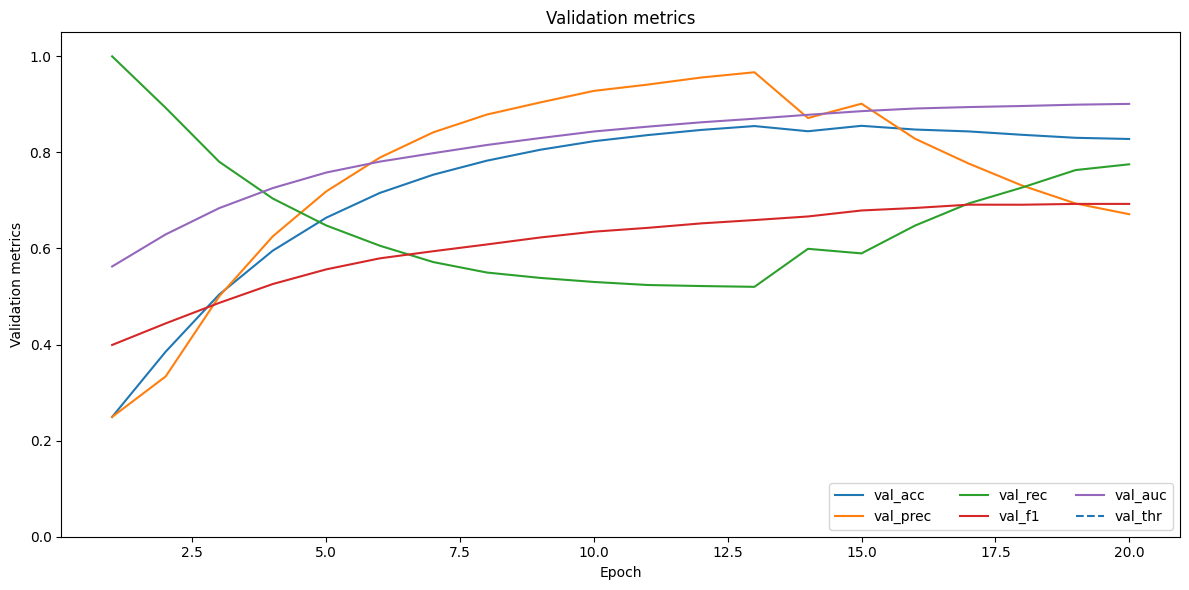

In [37]:

# -------------------------
# Plot metrics (one chart)
# -------------------------
import matplotlib.pyplot as plt

def ema(x, a=0.25):
    out, m = [], None
    for v in x:
        m = v if m is None else a*v + (1-a)*m
        out.append(m)
    return np.array(out)

epochs = np.arange(1, len(metrics_hist["val_auc"])+1)
plt.figure(figsize=(12,6))
ax = plt.gca()
for k in ["val_acc","val_prec","val_rec","val_f1","val_auc"]:
    ax.plot(epochs, ema(metrics_hist[k], 0.25), label=k)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation metrics")

# ax2 = ax.twinx()
# ax2.plot(epochs, metrics_hist["val_thr"], "--", label="val_thr")
# ax2.set_ylabel("Threshold")

lines, labels = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lab2, loc="lower right", ncol=3)
plt.title("Validation metrics")
plt.tight_layout()
plt.show()

**SMD plain**

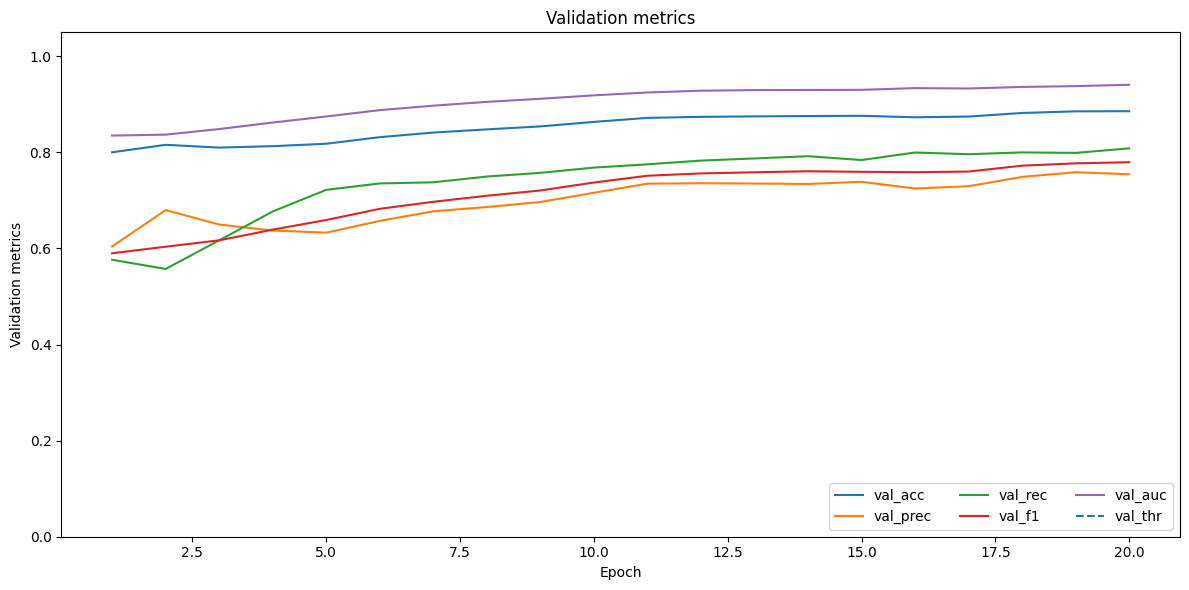

In [49]:

# -------------------------
# Plot metrics (one chart)
# -------------------------
import matplotlib.pyplot as plt

def ema(x, a=0.25):
    out, m = [], None
    for v in x:
        m = v if m is None else a*v + (1-a)*m
        out.append(m)
    return np.array(out)

epochs = np.arange(1, len(metrics_hist["val_auc"])+1)
plt.figure(figsize=(12,6))
ax = plt.gca()
for k in ["val_acc","val_prec","val_rec","val_f1","val_auc"]:
    ax.plot(epochs, ema(metrics_hist[k], 0.25), label=k)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation metrics")

# ax2 = ax.twinx()
# ax2.plot(epochs, metrics_hist["val_thr"], "--", label="val_thr")
# ax2.set_ylabel("Threshold")

lines, labels = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lab2, loc="lower right", ncol=3)
plt.title("Validation metrics")
plt.tight_layout()
plt.show()